In [13]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR         = '/home/bagga/Desktop/onera_468_crm_internship/mini-automl/.FILES_RHO_ALL_POINTS_reduitfloat32/'

np_pts = 260774
n_sims = 10

X = np.load(DATA_DIR + 'X9_ALL_POINT_fl32.npy')
y = np.load(DATA_DIR + 'RHO_ALL_POINT_fl32.npy')[:, 0]

nf = X.shape[0] // np_pts
sim_ids = np.random.choice(nf, size=n_sims, replace=False)

samples = np.concatenate([y[i*np_pts:(i+1)*np_pts] for i in sim_ids])

In [4]:
samples.shape

(3911610,)

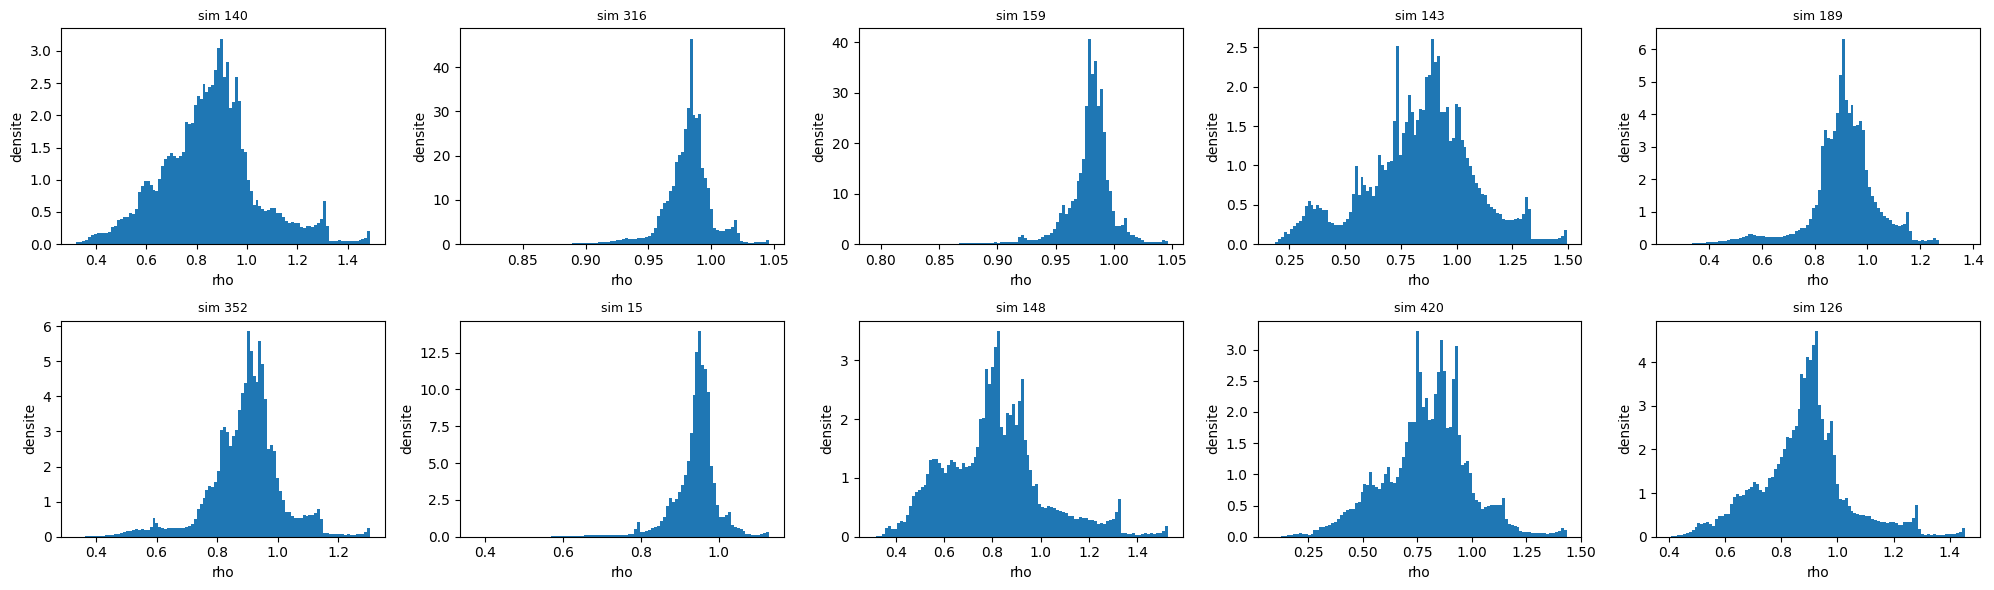

In [14]:
n_cols = 5
n_rows = int(np.ceil(n_sims / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, i in zip(axes, sim_ids):
    sim_rho = y[i*np_pts:(i+1)*np_pts]
    ax.hist(sim_rho, bins=100, density=True)
    ax.set_title(f'sim {i}', fontsize=9)
    ax.set_xlabel('rho')
    ax.set_ylabel('densite')

for ax in axes[len(sim_ids):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

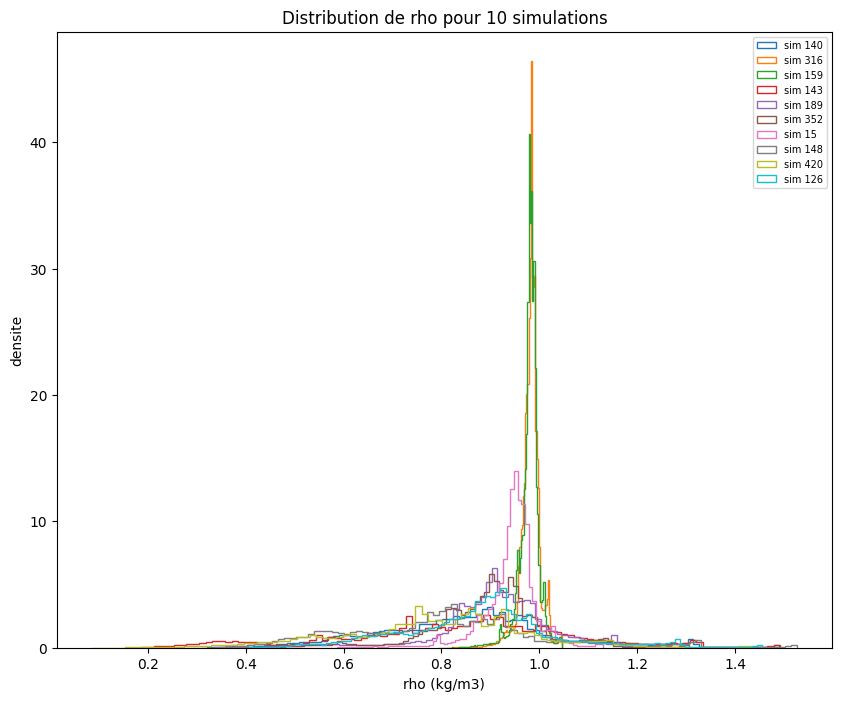

In [15]:
plt.figure(figsize=(10, 8))
for i in sim_ids:
    sim_rho = y[i*np_pts:(i+1)*np_pts]
    plt.hist(sim_rho, bins=100, density=True, histtype='step', label=f'sim {i}')
plt.xlabel('rho (kg/m3)')
plt.ylabel('densite')
plt.title(f'Distribution de rho pour {n_sims} simulations')
plt.legend(fontsize=7)
plt.show()

In [18]:
minf = X[::np_pts, 6]
aoa = X[::np_pts, 7]
pi = X[::np_pts, 8]

sim_mean_rho = np.array([y[i*np_pts:(i+1)*np_pts].mean() for i in range(nf)])

def plot_mean_shift(values, label):
    uniq = np.unique(values)
    mean_per_value = [sim_mean_rho[values == v].mean() for v in uniq]

    plt.figure(figsize=(8, 5))
    plt.plot(uniq, mean_per_value, marker='o')
    plt.xlabel(label)
    plt.ylabel('rho moyen (kg/m3)')
    plt.title(f'rho moyen en fonction de {label}')
    plt.show()

In [31]:
np.unique(minf)

array([0.3 , 0.5 , 0.7 , 0.75, 0.8 , 0.82, 0.84, 0.85, 0.86, 0.88, 0.9 ,
       0.93, 0.96], dtype=float32)

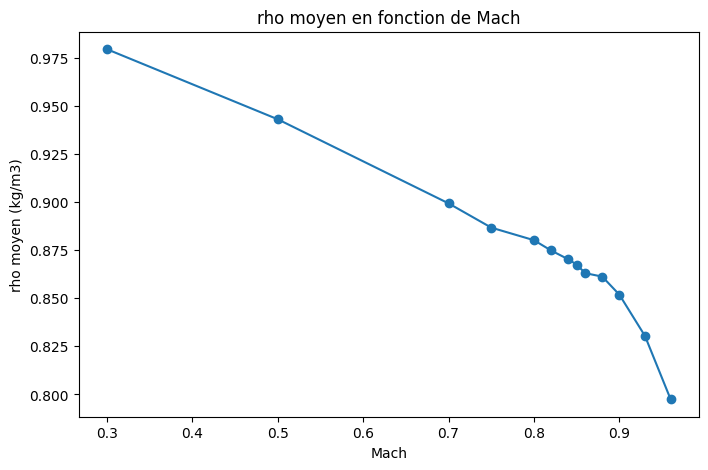

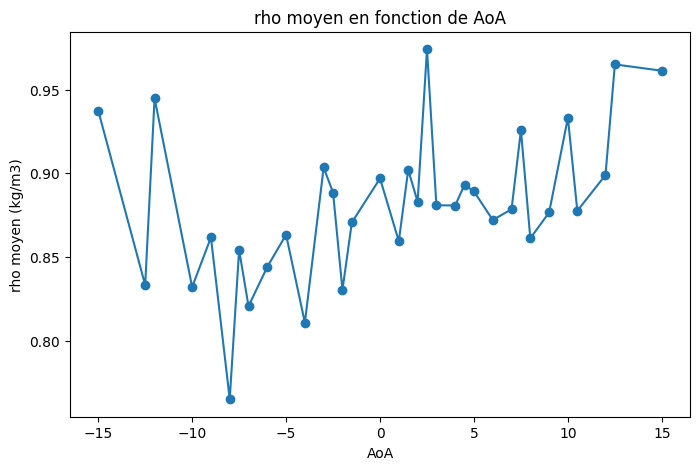

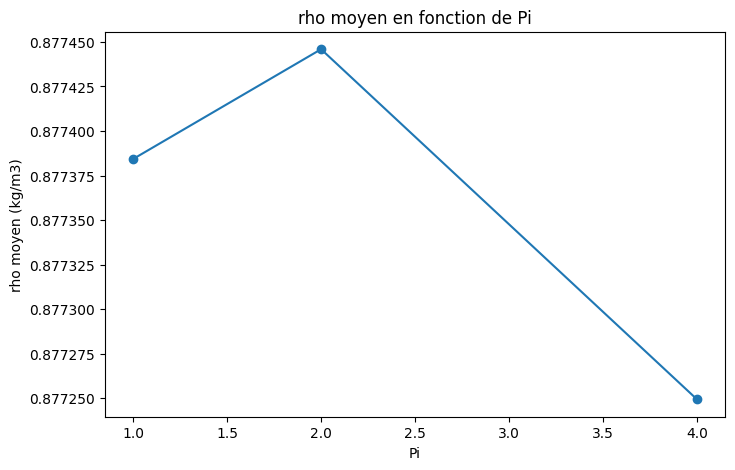

In [19]:
plot_mean_shift(minf, 'Mach')
plot_mean_shift(aoa, 'AoA')
plot_mean_shift(pi, 'Pi')

In [34]:
def plot_density_per_value(values, label, cmap='viridis'):
    uniq = np.unique(values)
    norm = plt.Normalize(uniq.min(), uniq.max())
    colors = plt.get_cmap(cmap)(norm(uniq))

    xlo, xhi = np.percentile(y, [0.5, 99.5])

    fig, ax = plt.subplots(figsize=(8, 5))
    for v, c in zip(uniq, colors):
        sims = np.where(values == v)[0]
        rho_pool = np.concatenate([y[i*np_pts:(i+1)*np_pts] for i in sims])
        ax.hist(rho_pool, bins=100, range=(xlo, xhi), density=True, histtype='step', color=c)

    ax.set_xlim(xlo, xhi)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=label)
    ax.set_xlabel('rho (kg/m3)')
    ax.set_ylabel('densite')
    ax.set_title(f'Densite de rho pour chaque valeur de {label}')
    plt.show()

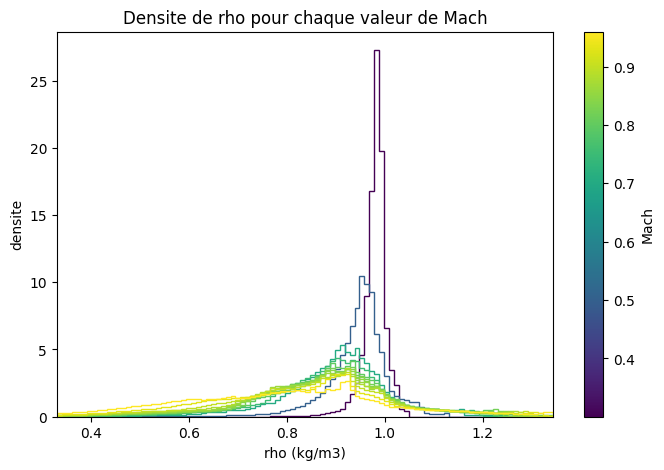

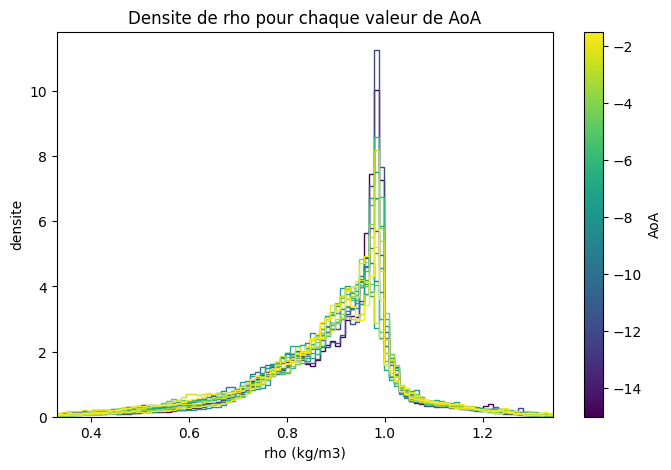

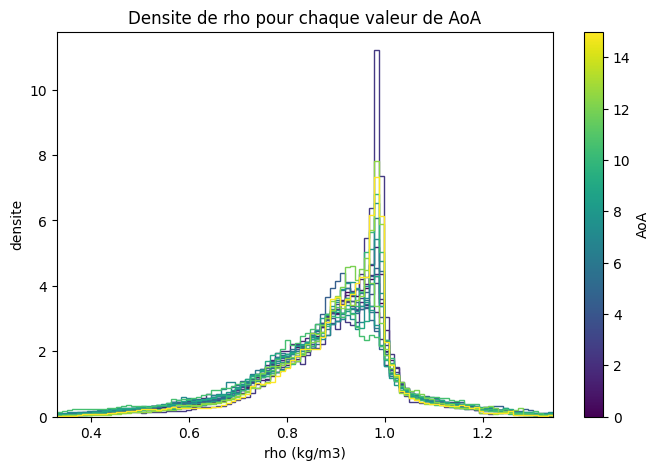

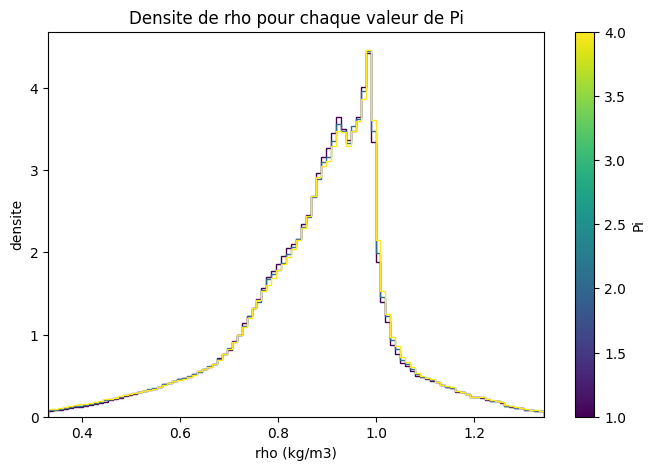

In [35]:
plot_density_per_value(minf, 'Mach')
plot_density_per_value(aoa[aoa<0], 'AoA')
plot_density_per_value(aoa[aoa>=0], 'AoA')
plot_density_per_value(pi, 'Pi')